CHURN PREDICTOR [MODEL TRAINING]

A classifier that predicts whether a telecom customer is likely to churn, trained on the IBM Telco Customer Churn dataset.

Dataset: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Imports

In [ ]:
# Core libraries: data handling, modeling, evaluation, and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

import joblib

SEED = 42
np.random.seed(SEED)

Connect to the dataset (kagglehub)

In [ ]:
import kagglehub

# Connects directly to the dataset rather than a manual CSV upload.
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


Locate and load the CSV

In [ ]:
import os

csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print("Loaded:", csv_file)
df.head()

Loaded: WA_Fn-UseC_-Telco-Customer-Churn.csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Check shape

In [ ]:
df.shape

(7043, 21)

Check data types

In [ ]:
df.info()
# NOTE: TotalCharges shows up as an "object" (text) column, not numeric --
# that's a known quirk of this dataset we'll fix in the next cell.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Fix TotalCharges (known dataset quirk)

In [ ]:
# TotalCharges is stored as text, and a small number of rows have a blank
# string instead of a number -- these are new customers with 0 months of
# tenure, so their total spend is genuinely 0, not missing at random.

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Rows with missing TotalCharges:", df['TotalCharges'].isnull().sum())

df['TotalCharges'] = df['TotalCharges'].fillna(0)
df['TotalCharges'].isnull().sum()

Rows with missing TotalCharges: 11


np.int64(0)

Drop the customer ID column

In [ ]:
# customerID is a unique identifier with no predictive value -- pure noise to a model.
df = df.drop(columns=['customerID'])

Check for duplicates

In [ ]:
df.duplicated().sum()

np.int64(22)

Check target balance (Stay vs Churn)

In [ ]:
df['Churn'].value_counts()
# This dataset is moderately imbalanced -- roughly 3 out of 4 customers stay.
# We'll account for this when training (class weighting) and when evaluating
# (recall on the Churn class matters more than raw accuracy).

,count
Churn,
No,5174
Yes,1869


EDA: churn by contract type

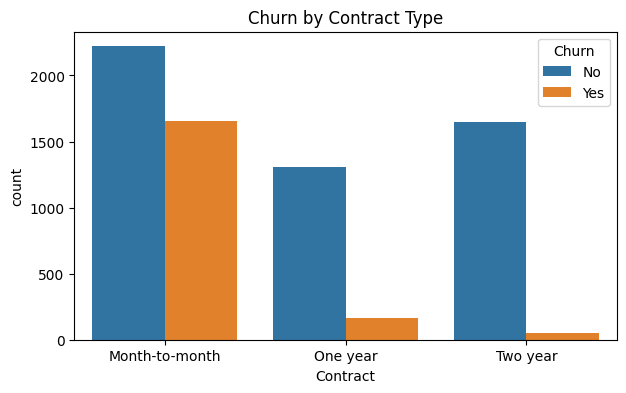

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')
plt.show()
# Contract length is famously the single biggest churn driver in this dataset --
# month-to-month customers churn far more than 1-2 year contract holders.

EDA: tenure and monthly charges by churn

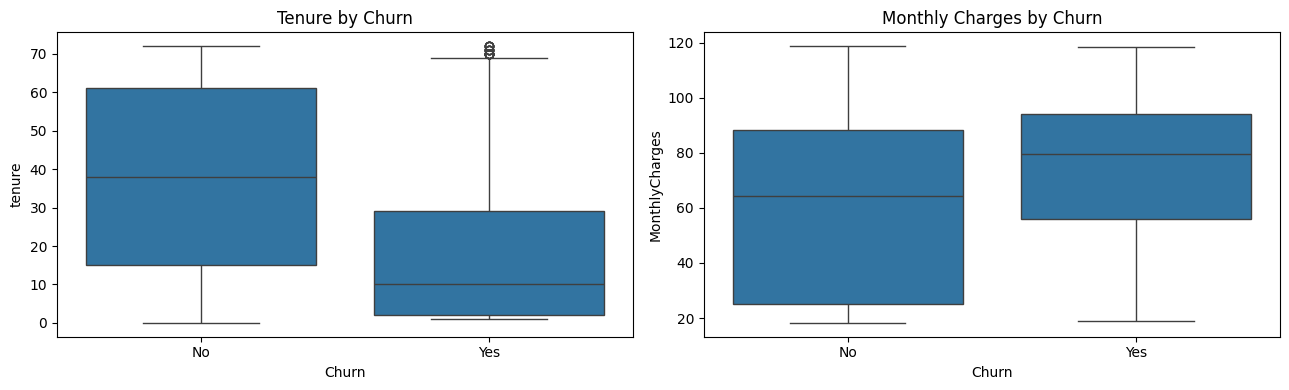

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0])
axes[0].set_title('Tenure by Churn')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1])
axes[1].set_title('Monthly Charges by Churn')

plt.tight_layout()
plt.show()

EDA: correlation heatmap

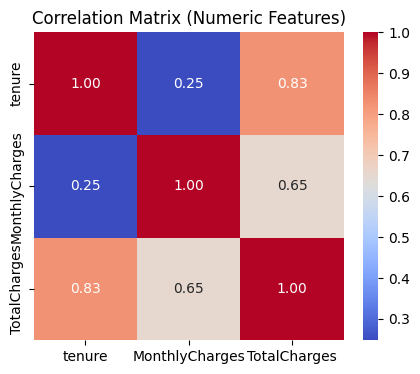

In [ ]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(5, 4))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix (Numeric Features)')
plt.show()

Encode binary Yes/No columns

In [ ]:
# Simple binary columns (Yes/No, or Male/Female) get mapped to 0/1 directly --
# using one-hot encoding here would be redundant since there are only 2 options.
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df[binary_cols].head()

,gender,Partner,Dependents,PhoneService,PaperlessBilling,Churn
0,0,1,0,0,1,0
1,1,0,0,1,0,0
2,1,0,0,1,1,1
3,1,0,0,0,0,0
4,0,0,0,1,1,1


One-hot encode multi-category columns

In [ ]:
# Columns with 3+ categories (e.g. "Yes" / "No" / "No internet service") get
# one-hot encoded instead of label-encoded -- label encoding would incorrectly
# imply an order between categories that don't actually have one.
multi_cat_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True, dtype=int)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


Feature/target split

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

feature_columns = X.columns.tolist()  # save this order -- the deployed app must match it exactly
print(f"Total features: {len(feature_columns)}")

Total features: 30


Train/test split

In [ ]:
# stratify=y keeps the same churn/non-churn ratio in both sets, since the classes are imbalanced.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (5634, 30) Test: (1409, 30)


Scale numeric features

In [ ]:
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

Compute the class imbalance ratio

In [ ]:
num_stay = (y_train == 0).sum()
num_churn = (y_train == 1).sum()
scale_pos_weight = num_stay / num_churn  # used by XGBoost/LightGBM to weigh the rarer class more

print(f"Stay: {num_stay}, Churn: {num_churn}, scale_pos_weight: {scale_pos_weight:.2f}")

Stay: 4139, Churn: 1495, scale_pos_weight: 2.77


Define candidate models

In [ ]:
# Comparing several models rather than assuming one upfront -- same approach
# as our very first project. class_weight='balanced' (or scale_pos_weight for
# the boosting models) tells each model to pay more attention to the
# minority (Churn) class instead of optimizing for the majority class alone.

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1),
    "XGBoost": XGBClassifier(
        scale_pos_weight=scale_pos_weight, random_state=SEED,
        eval_metric='logloss', tree_method='hist'
    ),
    "LightGBM": LGBMClassifier(
        scale_pos_weight=scale_pos_weight, random_state=SEED, verbose=-1
    ),
}

Define hyperparameter grids

In [ ]:
param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "penalty": ["l2"],
        "solver": ["lbfgs"]
    },
    "Random Forest": {
        "n_estimators": [200, 300, 500],
        "max_depth": [5, 8, 12, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },
    "XGBoost": {
        "n_estimators": [200, 300, 500],
        "max_depth": [3, 4, 5, 6],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.7, 0.8, 1.0],
        "colsample_bytree": [0.7, 0.8, 1.0]
    },
    "LightGBM": {
        "n_estimators": [200, 300, 500],
        "num_leaves": [15, 31, 50],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.7, 0.8, 1.0]
    }
}

Set up cross-validation

In [ ]:
# StratifiedKFold (rather than plain KFold) keeps the churn/non-churn ratio
# consistent across every fold -- important given the class imbalance.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

Run the model search

In [ ]:
best_model = None
best_score = -float("inf")
best_model_name = ""
results = {}

for name, model in models.items():
    print(f"\nRunning RandomizedSearchCV for {name}...")

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grids[name],
        n_iter=25,
        cv=cv,
        scoring='roc_auc',   # ROC-AUC is a more reliable ranking metric than accuracy for imbalanced data
        n_jobs=-1,
        random_state=SEED
    )
    search.fit(X_train, y_train)

    results[name] = {
        "Best Params": search.best_params_,
        "Best CV ROC-AUC": search.best_score_
    }

    print(f"{name} -- Best CV ROC-AUC: {search.best_score_:.4f}")

    if search.best_score_ > best_score:
        best_score = search.best_score_
        best_model = search.best_estimator_
        best_model_name = name


Running RandomizedSearchCV for Logistic Regression...


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=25. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Logistic Regression -- Best CV ROC-AUC: 0.8462

Running RandomizedSearchCV for Random Forest...
Random Forest -- Best CV ROC-AUC: 0.8469

Running RandomizedSearchCV for XGBoost...
XGBoost -- Best CV ROC-AUC: 0.8489

Running RandomizedSearchCV for LightGBM...
LightGBM -- Best CV ROC-AUC: 0.8465


Compare results across models

In [ ]:
results_df = pd.DataFrame(results).T
results_df.sort_values(by="Best CV ROC-AUC", ascending=False)

,Best Params,Best CV ROC-AUC
XGBoost,"{'subsample': 0.8, 'n_estimators': 500, 'max_d...",0.848853
Random Forest,"{'n_estimators': 200, 'min_samples_split': 10,...",0.846856
LightGBM,"{'subsample': 0.7, 'num_leaves': 15, 'n_estima...",0.846482
Logistic Regression,"{'solver': 'lbfgs', 'penalty': 'l2', 'C': 10}",0.846198


Announce the winning model

In [ ]:
print("Best Model:", best_model_name)
print("Best CV ROC-AUC:", best_score)

Best Model: XGBoost
Best CV ROC-AUC: 0.8488526284322921


Evaluate on the test set

In [ ]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]  # probability of churn

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Stay', 'Churn']))

roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {roc_auc:.4f}")

# The recall on "Churn" matters most here -- missing an at-risk customer
# (false negative) means losing them with no retention attempt at all.
report = classification_report(y_test, y_pred, target_names=['Stay', 'Churn'], output_dict=True)
print(f"\nChurn recall: {report['Churn']['recall']:.4f}  <-- most important single number for this project")

Classification Report:
              precision    recall  f1-score   support

        Stay       0.91      0.73      0.81      1035
       Churn       0.52      0.81      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409

ROC-AUC: 0.8462

Churn recall: 0.8075  <-- most important single number for this project


Confusion matrix

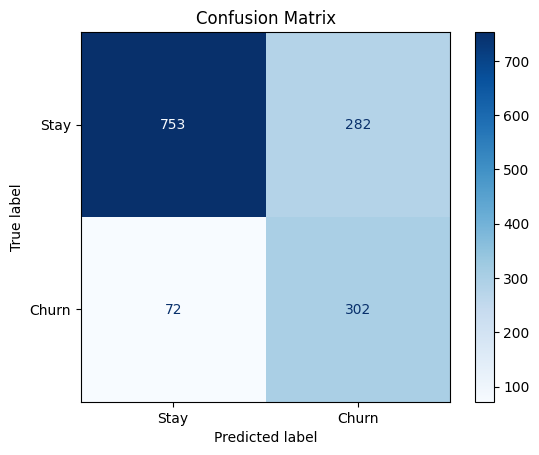

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay', 'Churn'])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

ROC curve

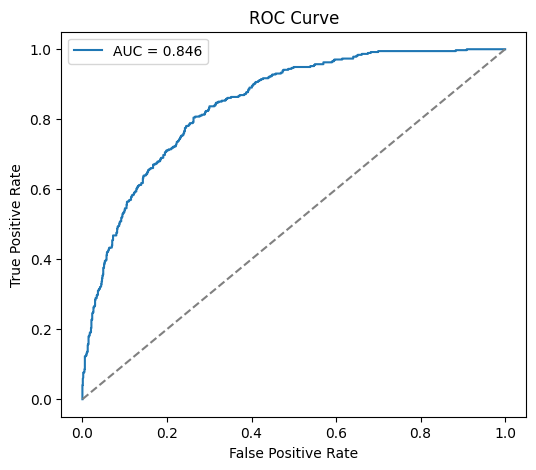

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Feature importance (churn drivers)

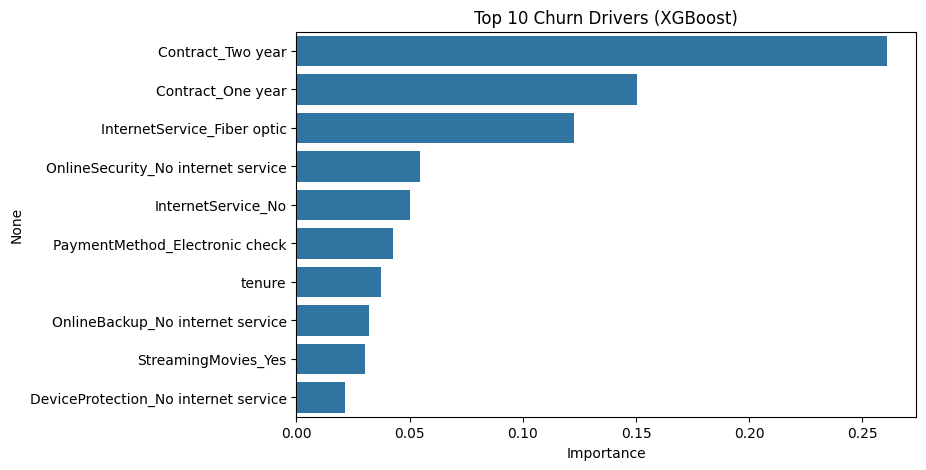

In [ ]:
# Which features actually drive the prediction? This feeds directly into the
# retention agent later -- it needs to know WHY a customer is high-risk, not
# just the final probability.

if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=feature_columns)
elif hasattr(best_model, "coef_"):
    importances = pd.Series(best_model.coef_[0], index=feature_columns).abs()
else:
    importances = None

if importances is not None:
    top_features = importances.sort_values(ascending=False).head(10)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=top_features.values, y=top_features.index)
    plt.title(f"Top 10 Churn Drivers ({best_model_name})")
    plt.xlabel("Importance")
    plt.show()

Save model artifacts

In [ ]:
joblib.dump(best_model, 'churn_best_model.joblib')
joblib.dump(scaler, 'churn_scaler.joblib')
joblib.dump(feature_columns, 'churn_feature_columns.joblib')
joblib.dump(numeric_cols, 'churn_numeric_cols.joblib')

print("Model, scaler, and feature columns saved successfully!")

Model, scaler, and feature columns saved successfully!


## Part 2: The Retention Agent

The model tells us WHO is at risk. This section builds the piece that decides WHAT TO DO about it -- an LLM agent that reads a customer's risk profile and drafts a short, personalized retention email.

Install the Groq SDK

In [ ]:
!pip install groq --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 5.3 MB/s eta 0:00:00


Provide your Groq API key (kept out of the notebook itself)

In [ ]:
import getpass
import os

# getpass hides the input as you type, and the key is never printed or saved
# anywhere in this notebook -- same practice we'll carry into deployment,
# where it becomes a Railway environment variable instead.
#
# Get a free key at https://console.groq.com -> API Keys -> Create Key
os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

Enter your Groq API key: ··········


Define the retention email generator

In [ ]:
from groq import Groq

client = Groq()  # reads the key from the GROQ_API_KEY environment variable

AGENT_SYSTEM_PROMPT = """You are a customer retention specialist at a telecom company.
You write short, warm, non-desperate retention emails to customers flagged as at risk of
cancelling. Rules:
- Under 120 words.
- Reference the customer's specific situation using the risk factors provided -- never
  invent details you were not given.
- Offer exactly ONE concrete, specific incentive relevant to their situation (e.g. a
  discount tied to their contract type, or a free add-on relevant to a service they lack).
- Never sound desperate or use guilt. Tone: genuinely helpful, not salesy.
- Sign off as "The [Company] Customer Care Team".
- Output ONLY the email body -- no subject line, no explanation, no markdown."""


def generate_retention_email(customer_summary, churn_probability, top_drivers, company_name="GreenLine Telecom"):
    user_prompt = f"""Company name: {company_name}
Customer summary: {customer_summary}
Predicted churn probability: {churn_probability:.0%}
Top risk factors driving this prediction: {", ".join(top_drivers)}

Write the retention email now."""

    # Groq uses the same chat-style message format as OpenAI: the system
    # instructions go in as the first message, rather than a separate
    # "system" parameter like Anthropic's SDK uses.
    response = client.chat.completions.create(
        model="openai/gpt-oss-20b",  # Groq deprecated their Llama chat models -- this is their current
        # recommended general-purpose model. Swap to "openai/gpt-oss-120b" for higher quality.
        max_tokens=1500,
        messages=[
            {"role": "system", "content": AGENT_SYSTEM_PROMPT},
            {"role": "user", "content": user_prompt}
        ]
    )

    return response.choices[0].message.content

Test the agent on a sample high-risk customer

In [ ]:
sample_customer_summary = (
    "Month-to-month contract, 2 months tenure, $95.20 monthly charge, "
    "fiber optic internet, no online security, pays by electronic check."
)
sample_drivers = [
    "month-to-month contract",
    "fiber optic internet service",
    "no online security add-on",
    "pays by electronic check"
]

email = generate_retention_email(
    customer_summary=sample_customer_summary,
    churn_probability=0.83,
    top_drivers=sample_drivers
)

print(email)

Hi there,

We’ve noticed you’re on a month‑to‑month plan with our fiber‑optic service, and you haven’t added the online security package yet. To make your experience even smoother, we’d like to offer you a complimentary 6‑month online security add‑on, just for you. It’s a simple way to keep your home network safe while you continue enjoying our high‑speed internet.

We’re glad you’re with us and hope this helps. If you’d like to activate the add‑on or have any questions, just let us know.

The GreenLine Telecom Customer Care Team


Test the agent on a low-risk customer (confirm the tone adapts appropriately)

In [ ]:
sample_customer_summary_low = (
    "Two-year contract, 58 months tenure, $65.10 monthly charge, "
    "DSL internet, has online security, pays by automatic bank transfer."
)
sample_drivers_low = ["long tenure", "two-year contract", "has online security add-on"]

email_low = generate_retention_email(
    customer_summary=sample_customer_summary_low,
    churn_probability=0.12,
    top_drivers=sample_drivers_low
)

print(email_low)
# NOTE: a genuinely low-risk customer probably shouldn't get an urgent "don't leave!"
# email at all -- in the deployed app, we'll likely only trigger email generation
# above a certain probability threshold. This test is here to sanity-check that the
# agent's tone stays calm and non-desperate even when we DO call it for a lower-risk case.

Hi [Name],

We’ve noticed you’ve been with GreenLine Telecom for nearly 5 years and enjoy our DSL service with online security. We’re grateful for your loyalty and want to make your experience even better. As a thank you, we’ll reduce your monthly fee by $10 for the next 12 months of your existing contract. This is our way of showing appreciation for staying with us.

Thank you for choosing GreenLine. If you have questions, we’re here.

The GreenLine Customer Care Team


A note on where this is heading:

In the deployed app, this same `generate_retention_email` logic moves into `app/agent.py`, and `GROQ_API_KEY` becomes an environment variable set directly in Railway's dashboard -- never committed to GitHub. The model's churn probability and top feature drivers (from Part 1) become the real inputs to this function, replacing the hardcoded sample values used above for testing.

## Part 3: Package for Deployment

Combines the trained model (Part 1) and the retention agent (Part 2) into a deployable FastAPI app with a full dashboard UI.

Create the deploy folder structure

In [ ]:
import os

project_root = "churn_deploy"
folders = [
    f"{project_root}/app",
    f"{project_root}/app/templates",
    f"{project_root}/models",
]
for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project structure created.")

Project structure created.


Copy the saved model artifacts into the deploy folder

In [ ]:
import shutil

for fname in ["churn_best_model.joblib", "churn_scaler.joblib", "churn_feature_columns.joblib", "churn_numeric_cols.joblib"]:
    shutil.copy(fname, f"{project_root}/models/{fname}")

print("Model artifacts copied.")

Model artifacts copied.


Write app/model.py

In [ ]:
%%writefile churn_deploy/app/model.py
# Loads the trained model and preprocessing objects, and turns a raw form
# submission (human-readable values like "Month-to-month", "Fiber optic")
# into the exact numeric feature vector the model expects.

import os
import joblib
import numpy as np
import pandas as pd
import xgboost as xgb

BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
MODELS_DIR = os.path.join(BASE_DIR, "models")

BINARY_MAP_COLS = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
MULTI_CAT_COLS = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]


def load_artifacts():
    model = joblib.load(os.path.join(MODELS_DIR, "churn_best_model.joblib"))
    scaler = joblib.load(os.path.join(MODELS_DIR, "churn_scaler.joblib"))
    feature_columns = joblib.load(os.path.join(MODELS_DIR, "churn_feature_columns.joblib"))
    numeric_cols = joblib.load(os.path.join(MODELS_DIR, "churn_numeric_cols.joblib"))
    return model, scaler, feature_columns, numeric_cols


def preprocess_input(raw: dict, scaler, feature_columns, numeric_cols):
    """Mirrors the exact preprocessing steps used in training (Part 1), so a raw
    form submission gets encoded and scaled identically to the training data."""

    df = pd.DataFrame([raw])

    # Binary Yes/No and gender columns -> 0/1, same mapping as training
    df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
    for col in BINARY_MAP_COLS:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

    # One-hot encode multi-category columns -- identical call to training
    df = pd.get_dummies(df, columns=MULTI_CAT_COLS, drop_first=True, dtype=int)

    # Align to the exact column set/order the model was trained on. Any
    # dummy column not produced by this single row (e.g. because this
    # customer's category was the "dropped" baseline) is filled with 0.
    df = df.reindex(columns=feature_columns, fill_value=0)

    # Scale numeric features using the SAME scaler fitted during training
    df[numeric_cols] = scaler.transform(df[numeric_cols])

    return df


def predict_churn(raw: dict, model, scaler, feature_columns, numeric_cols, top_k=5):
    row_df = preprocess_input(raw, scaler, feature_columns, numeric_cols)
    probability = float(model.predict_proba(row_df)[0][1])

    # Per-customer explanation: XGBoost can report exactly how much each
    # feature pushed THIS specific prediction up or down (not just a global
    # "importance" chart that looks the same for every customer).
    top_drivers = []
    try:
        booster = model.get_booster()
        dmatrix = xgb.DMatrix(row_df, feature_names=feature_columns)
        contribs = booster.predict(dmatrix, pred_contribs=True)[0][:-1]  # drop bias term
        contrib_series = pd.Series(contribs, index=feature_columns)

        # Only factors pushing risk UP are useful to show as "why this customer is at risk"
        top_positive = contrib_series[contrib_series > 0].sort_values(ascending=False).head(top_k)
        top_drivers = [{"feature": _clean_label(f), "impact": float(v)} for f, v in top_positive.items()]
    except Exception:
        # Fallback for non-XGBoost models: global feature importances instead
        if hasattr(model, "feature_importances_"):
            importances = pd.Series(model.feature_importances_, index=feature_columns)
            top = importances.sort_values(ascending=False).head(top_k)
            top_drivers = [{"feature": _clean_label(f), "impact": float(v)} for f, v in top.items()]

    if probability >= 0.6:
        risk_band = "High"
    elif probability >= 0.3:
        risk_band = "Medium"
    else:
        risk_band = "Low"

    return {
        "probability": probability,
        "risk_band": risk_band,
        "top_drivers": top_drivers,
    }


def _clean_label(feature_name):
    """Turns a raw one-hot column name like "Contract_Two year" into a
    readable label like "Contract: Two year" for display in the UI."""
    for cat_col in MULTI_CAT_COLS:
        if feature_name.startswith(cat_col + "_"):
            return f"{cat_col}: {feature_name[len(cat_col) + 1:]}"
    return feature_name

Overwriting churn_deploy/app/model.py


Write app/agent.py

In [ ]:
%%writefile churn_deploy/app/agent.py
# Wraps the retention email generator built and tested in Part 2. Reads the
# GROQ_API_KEY from the environment -- set as a Railway environment variable
# in the deployed app, never committed to the repo.

import os
from groq import Groq

client = Groq(api_key=os.environ.get("GROQ_API_KEY"))

AGENT_SYSTEM_PROMPT = """You are a customer retention specialist at a telecom company.
You write short, warm, non-desperate retention emails to customers flagged as at risk of
cancelling. Rules:
- Under 120 words.
- Reference the customer's specific situation using the risk factors provided -- never
  invent details you were not given.
- Offer exactly ONE concrete, specific incentive relevant to their situation (e.g. a
  discount tied to their contract type, or a free add-on relevant to a service they lack).
- Never sound desperate or use guilt. Tone: genuinely helpful, not salesy.
- If a customer name is provided, greet them by name. If no name is provided, use a
  warm generic greeting like "Hi there" -- never write a placeholder like "[Name]".
- Sign off as "The [Company] Customer Care Team".
- Output ONLY the email body -- no subject line, no explanation, no markdown."""


def generate_retention_email(customer_summary, churn_probability, top_drivers, company_name="GreenLine Telecom", customer_name=None):
    name_line = f"Customer name: {customer_name}" if customer_name else "Customer name: not provided"

    user_prompt = f"""Company name: {company_name}
{name_line}
Customer summary: {customer_summary}
Predicted churn probability: {churn_probability:.0%}
Top risk factors driving this prediction: {", ".join(top_drivers)}

Write the retention email now."""

    response = client.chat.completions.create(
        model="openai/gpt-oss-20b",
        max_tokens=1500,
        messages=[
            {"role": "system", "content": AGENT_SYSTEM_PROMPT},
            {"role": "user", "content": user_prompt}
        ]
    )

    return response.choices[0].message.content

Overwriting churn_deploy/app/agent.py


Write app/main.py

In [ ]:
%%writefile churn_deploy/app/main.py
# The FastAPI app. Two JSON endpoints (predict, generate-email) power a
# single-page dashboard that updates without full page reloads.

from fastapi import FastAPI, Request
from fastapi.responses import HTMLResponse
from fastapi.templating import Jinja2Templates
from pydantic import BaseModel

from app.model import load_artifacts, predict_churn
from app.agent import generate_retention_email

app = FastAPI(title="Churn Predictor & Retention Agent")
templates = Jinja2Templates(directory="app/templates")

model, scaler, feature_columns, numeric_cols = load_artifacts()


class CustomerInput(BaseModel):
    gender: str
    SeniorCitizen: int
    Partner: str
    Dependents: str
    tenure: int
    PhoneService: str
    MultipleLines: str
    InternetService: str
    OnlineSecurity: str
    OnlineBackup: str
    DeviceProtection: str
    TechSupport: str
    StreamingTV: str
    StreamingMovies: str
    Contract: str
    PaperlessBilling: str
    PaymentMethod: str
    MonthlyCharges: float
    TotalCharges: float


class EmailRequest(BaseModel):
    customer_summary: str
    churn_probability: float
    top_drivers: list[str]


@app.get("/", response_class=HTMLResponse)
def index(request: Request):
    return templates.TemplateResponse("index.html", {"request": request})


@app.post("/predict")
def predict(payload: CustomerInput):
    result = predict_churn(payload.dict(), model, scaler, feature_columns, numeric_cols)
    return result


@app.post("/generate-email")
def generate_email(payload: EmailRequest):
    email_text = generate_retention_email(
        customer_summary=payload.customer_summary,
        churn_probability=payload.churn_probability,
        top_drivers=payload.top_drivers
    )
    return {"email": email_text}


@app.get("/health")
def health():
    return {"status": "ok"}

Overwriting churn_deploy/app/main.py


Write app/__init__.py

In [ ]:
%%writefile churn_deploy/app/__init__.py

Overwriting churn_deploy/app/__init__.py


Write app/templates/index.html (immersive dashboard UI)

In [ ]:
%%writefile churn_deploy/app/templates/index.html
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>Churn Intelligence Dashboard</title>
<link rel="preconnect" href="https://fonts.googleapis.com">
<link href="https://fonts.googleapis.com/css2?family=Outfit:wght@500;600;700&family=Inter:wght@400;500;600&family=JetBrains+Mono:wght@500;600&display=swap" rel="stylesheet">
<style>
  :root {
    --bg: #0B1120;
    --bg-2: #0F1729;
    --card: rgba(255,255,255,0.045);
    --card-border: rgba(255,255,255,0.09);
    --text: #EAF0FF;
    --text-muted: #8996B0;
    --accent: #6C8CFF;
    --accent-soft: rgba(108,140,255,0.15);
    --safe: #34D399;
    --watch: #FBBF24;
    --high: #FB6B6B;
    --radius: 16px;
  }
  * { box-sizing: border-box; }
  body {
    margin: 0;
    background: radial-gradient(1200px 600px at 15% -10%, #16213F 0%, var(--bg) 55%);
    color: var(--text);
    font-family: 'Inter', sans-serif;
    min-height: 100vh;
  }
  .mono { font-family: 'JetBrains Mono', monospace; }
  header {
    padding: 26px 32px;
    display: flex;
    align-items: center;
    gap: 12px;
    border-bottom: 1px solid var(--card-border);
  }
  header .mark {
    width: 36px; height: 36px;
    border-radius: 10px;
    background: linear-gradient(135deg, var(--accent), #A78BFA);
    display: flex; align-items: center; justify-content: center;
    font-family: 'Outfit', sans-serif; font-weight: 700; font-size: 0.95rem;
  }
  header h1 {
    font-family: 'Outfit', sans-serif;
    font-weight: 700;
    font-size: 1.2rem;
    margin: 0;
  }
  header .tagline { font-size: 0.82rem; color: var(--text-muted); }

  .layout {
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 22px;
    padding: 28px;
    max-width: 1200px;
    margin: 0 auto;
    align-items: start;
  }
  @media (max-width: 900px) { .layout { grid-template-columns: 1fr; } }

  .card {
    background: var(--card);
    border: 1px solid var(--card-border);
    border-radius: var(--radius);
    padding: 22px;
    backdrop-filter: blur(14px);
  }
  .card h2 {
    font-family: 'Outfit', sans-serif;
    font-size: 1rem;
    margin: 0 0 4px 0;
  }
  .card .sub { font-size: 0.8rem; color: var(--text-muted); margin-bottom: 16px; }

  /* Presets */
  .presets { display: flex; gap: 8px; margin-bottom: 18px; flex-wrap: wrap; }
  .preset-btn {
    font-size: 0.78rem;
    padding: 7px 12px;
    border-radius: 20px;
    border: 1px solid var(--card-border);
    background: rgba(255,255,255,0.03);
    color: var(--text);
    cursor: pointer;
  }
  .preset-btn:hover { border-color: var(--accent); color: var(--accent); }

  /* Collapsible sections */
  .section { border: 1px solid var(--card-border); border-radius: 10px; margin-bottom: 10px; overflow: hidden; }
  .section-header {
    padding: 12px 14px;
    background: rgba(255,255,255,0.02);
    cursor: pointer;
    display: flex; justify-content: space-between; align-items: center;
    font-size: 0.85rem; font-weight: 600;
  }
  .section-header .chev { transition: transform 0.2s; color: var(--text-muted); }
  .section.open .chev { transform: rotate(180deg); }
  .section-body {
    display: none;
    padding: 14px;
    grid-template-columns: 1fr 1fr;
    gap: 12px;
  }
  .section.open .section-body { display: grid; }

  .field label {
    display: block;
    font-size: 0.74rem;
    color: var(--text-muted);
    margin-bottom: 5px;
  }
  .field input, .field select {
    width: 100%;
    padding: 8px 10px;
    background: rgba(255,255,255,0.04);
    border: 1px solid var(--card-border);
    border-radius: 7px;
    color: var(--text);
    font-size: 0.85rem;
  }
  .field select option { background: #101828; }

  button.primary {
    width: 100%;
    margin-top: 16px;
    padding: 13px;
    background: linear-gradient(135deg, var(--accent), #8B7CFF);
    color: white;
    border: none;
    border-radius: 10px;
    font-family: 'Outfit', sans-serif;
    font-weight: 600;
    font-size: 0.92rem;
    cursor: pointer;
  }
  button.primary:hover { filter: brightness(1.08); }
  button.secondary {
    width: 100%;
    margin-top: 10px;
    padding: 11px;
    background: transparent;
    color: var(--accent);
    border: 1px solid var(--accent-soft);
    border-radius: 10px;
    font-size: 0.85rem;
    cursor: pointer;
  }
  button.secondary:hover { background: var(--accent-soft); }
  button:disabled { opacity: 0.5; cursor: not-allowed; }

  /* Gauge */
  .gauge-wrap { display: flex; flex-direction: column; align-items: center; margin-bottom: 18px; }
  .gauge-value { font-family: 'JetBrains Mono', monospace; font-size: 2.2rem; font-weight: 600; margin-top: -66px; }
  .risk-band {
    margin-top: 4px;
    font-size: 0.8rem;
    padding: 3px 12px;
    border-radius: 20px;
    font-weight: 600;
  }
  .band-low { background: rgba(52,211,153,0.15); color: var(--safe); }
  .band-medium { background: rgba(251,191,36,0.15); color: var(--watch); }
  .band-high { background: rgba(251,107,107,0.15); color: var(--high); }

  .driver-row { margin-bottom: 10px; }
  .driver-label { display: flex; justify-content: space-between; font-size: 0.82rem; margin-bottom: 4px; }
  .driver-bar-bg { background: rgba(255,255,255,0.06); border-radius: 6px; height: 8px; overflow: hidden; }
  .driver-bar-fill { height: 100%; background: linear-gradient(90deg, var(--accent), var(--high)); border-radius: 6px; width: 0%; transition: width 0.6s ease; }

  .empty-state { text-align: center; padding: 40px 10px; color: var(--text-muted); font-size: 0.85rem; }

  .email-card {
    margin-top: 18px;
    background: rgba(255,255,255,0.03);
    border: 1px solid var(--card-border);
    border-radius: 12px;
    padding: 16px;
    font-size: 0.85rem;
    line-height: 1.5;
    white-space: pre-wrap;
    display: none;
  }
  .email-card.visible { display: block; }
  .spinner {
    display: none;
    text-align: center;
    color: var(--text-muted);
    font-size: 0.8rem;
    margin-top: 10px;
  }
  .spinner.visible { display: block; }
</style>
</head>
<body>

<header>
  <div class="mark">CI</div>
  <div>
    <h1>Churn Intelligence Dashboard</h1>
    <div class="tagline">Predict risk. Understand why. Act on it.</div>
  </div>
</header>

<div class="layout">

  <!-- Input panel -->
  <div class="card">
    <h2>Customer Profile</h2>
    <div class="sub">Fill in details manually, or load a sample customer.</div>

    <div class="presets">
      <button type="button" class="preset-btn" onclick="loadPreset('high')">⚠ High-risk sample</button>
      <button type="button" class="preset-btn" onclick="loadPreset('low')">✓ Loyal customer sample</button>
    </div>

    <form id="customerForm">

      <div class="section open" data-section="demographics">
        <div class="section-header" onclick="toggleSection(this)">Demographics <span class="chev">▾</span></div>
        <div class="section-body">
          <div class="field"><label>Gender</label>
            <select name="gender"><option>Male</option><option>Female</option></select>
          </div>
          <div class="field"><label>Senior Citizen</label>
            <select name="SeniorCitizen"><option value="0">No</option><option value="1">Yes</option></select>
          </div>
          <div class="field"><label>Partner</label>
            <select name="Partner"><option>No</option><option>Yes</option></select>
          </div>
          <div class="field"><label>Dependents</label>
            <select name="Dependents"><option>No</option><option>Yes</option></select>
          </div>
        </div>
      </div>

      <div class="section" data-section="account">
        <div class="section-header" onclick="toggleSection(this)">Account <span class="chev">▾</span></div>
        <div class="section-body">
          <div class="field"><label>Tenure (months)</label><input type="number" name="tenure" value="12" min="0"></div>
          <div class="field"><label>Contract</label>
            <select name="Contract"><option>Month-to-month</option><option>One year</option><option>Two year</option></select>
          </div>
          <div class="field"><label>Paperless Billing</label>
            <select name="PaperlessBilling"><option>Yes</option><option>No</option></select>
          </div>
          <div class="field"><label>Payment Method</label>
            <select name="PaymentMethod">
              <option>Electronic check</option><option>Mailed check</option>
              <option>Bank transfer (automatic)</option><option>Credit card (automatic)</option>
            </select>
          </div>
        </div>
      </div>

      <div class="section" data-section="services">
        <div class="section-header" onclick="toggleSection(this)">Services <span class="chev">▾</span></div>
        <div class="section-body">
          <div class="field"><label>Phone Service</label><select name="PhoneService"><option>Yes</option><option>No</option></select></div>
          <div class="field"><label>Multiple Lines</label><select name="MultipleLines"><option>No</option><option>Yes</option><option>No phone service</option></select></div>
          <div class="field"><label>Internet Service</label><select name="InternetService"><option>Fiber optic</option><option>DSL</option><option>No</option></select></div>
          <div class="field"><label>Online Security</label><select name="OnlineSecurity"><option>No</option><option>Yes</option><option>No internet service</option></select></div>
          <div class="field"><label>Online Backup</label><select name="OnlineBackup"><option>No</option><option>Yes</option><option>No internet service</option></select></div>
          <div class="field"><label>Device Protection</label><select name="DeviceProtection"><option>No</option><option>Yes</option><option>No internet service</option></select></div>
          <div class="field"><label>Tech Support</label><select name="TechSupport"><option>No</option><option>Yes</option><option>No internet service</option></select></div>
          <div class="field"><label>Streaming TV</label><select name="StreamingTV"><option>No</option><option>Yes</option><option>No internet service</option></select></div>
          <div class="field"><label>Streaming Movies</label><select name="StreamingMovies"><option>No</option><option>Yes</option><option>No internet service</option></select></div>
        </div>
      </div>

      <div class="section" data-section="billing">
        <div class="section-header" onclick="toggleSection(this)">Billing <span class="chev">▾</span></div>
        <div class="section-body">
          <div class="field"><label>Monthly Charges ($)</label><input type="number" step="0.01" name="MonthlyCharges" value="70.00"></div>
          <div class="field"><label>Total Charges ($)</label><input type="number" step="0.01" name="TotalCharges" value="840.00"></div>
        </div>
      </div>

      <button type="submit" class="primary">Predict Churn Risk</button>
    </form>
  </div>

  <!-- Results panel -->
  <div class="card">
    <h2>Risk Assessment</h2>
    <div class="sub">Live churn probability and the factors driving it.</div>

    <div id="emptyState" class="empty-state">Submit a customer profile to see results here.</div>

    <div id="results" style="display:none;">
      <div class="gauge-wrap">
        <svg id="gaugeSvg" width="220" height="130" viewBox="0 0 220 130">
          <path d="M20,120 A90,90 0 0,1 200,120" fill="none" stroke="rgba(255,255,255,0.08)" stroke-width="16" stroke-linecap="round"/>
          <path id="gaugeArc" d="M20,120 A90,90 0 0,1 200,120" fill="none" stroke="url(#gaugeGradient)" stroke-width="16" stroke-linecap="round"
                stroke-dasharray="283" stroke-dashoffset="283" style="transition: stroke-dashoffset 1s ease;"/>
          <defs>
            <linearGradient id="gaugeGradient" x1="0%" y1="0%" x2="100%" y2="0%">
              <stop offset="0%" stop-color="#34D399"/>
              <stop offset="50%" stop-color="#FBBF24"/>
              <stop offset="100%" stop-color="#FB6B6B"/>
            </linearGradient>
          </defs>
        </svg>
        <div class="gauge-value mono" id="gaugeValue">0%</div>
        <div class="risk-band" id="riskBand">—</div>
      </div>

      <h2 style="margin-top:22px;">Top Risk Drivers</h2>
      <div id="driversList"></div>

      <button type="button" class="secondary" id="emailBtn" onclick="generateEmail()">✉ Generate Retention Email</button>
      <div class="spinner" id="emailSpinner">Writing email...</div>
      <div class="email-card" id="emailCard"></div>
    </div>
  </div>

</div>

<script>
let lastResult = null;

function toggleSection(headerEl) {
  headerEl.parentElement.classList.toggle('open');
}

const presets = {
  high: {
    gender: "Female", SeniorCitizen: "0", Partner: "No", Dependents: "No",
    tenure: 2, PhoneService: "Yes", MultipleLines: "No", InternetService: "Fiber optic",
    OnlineSecurity: "No", OnlineBackup: "No", DeviceProtection: "No", TechSupport: "No",
    StreamingTV: "Yes", StreamingMovies: "Yes", Contract: "Month-to-month",
    PaperlessBilling: "Yes", PaymentMethod: "Electronic check",
    MonthlyCharges: 95.20, TotalCharges: 190.40
  },
  low: {
    gender: "Male", SeniorCitizen: "0", Partner: "Yes", Dependents: "Yes",
    tenure: 58, PhoneService: "Yes", MultipleLines: "Yes", InternetService: "DSL",
    OnlineSecurity: "Yes", OnlineBackup: "Yes", DeviceProtection: "Yes", TechSupport: "Yes",
    StreamingTV: "No", StreamingMovies: "No", Contract: "Two year",
    PaperlessBilling: "No", PaymentMethod: "Bank transfer (automatic)",
    MonthlyCharges: 65.10, TotalCharges: 3775.80
  }
};

function loadPreset(kind) {
  const data = presets[kind];
  const form = document.getElementById('customerForm');
  for (const [key, value] of Object.entries(data)) {
    const el = form.elements[key];
    if (el) el.value = value;
  }
}

document.getElementById('customerForm').addEventListener('submit', async function (e) {
  e.preventDefault();
  const form = e.target;
  const data = {};
  for (const el of form.elements) {
    if (!el.name) continue;
    data[el.name] = ['tenure', 'SeniorCitizen'].includes(el.name) ? parseInt(el.value)
                     : ['MonthlyCharges', 'TotalCharges'].includes(el.name) ? parseFloat(el.value)
                     : el.value;
  }

  const res = await fetch('/predict', {
    method: 'POST',
    headers: { 'Content-Type': 'application/json' },
    body: JSON.stringify(data)
  });
  const result = await res.json();
  lastResult = { ...result, customerData: data };
  renderResult(result, data);
});

function renderResult(result, customerData) {
  document.getElementById('emptyState').style.display = 'none';
  document.getElementById('results').style.display = 'block';

  const pct = Math.round(result.probability * 100);
  document.getElementById('gaugeValue').textContent = pct + '%';

  const arc = document.getElementById('gaugeArc');
  const offset = 283 - (283 * result.probability);
  setTimeout(() => { arc.style.strokeDashoffset = offset; }, 50);

  const bandEl = document.getElementById('riskBand');
  bandEl.textContent = result.risk_band + ' Risk';
  bandEl.className = 'risk-band band-' + result.risk_band.toLowerCase();

  const driversList = document.getElementById('driversList');
  driversList.innerHTML = '';
  const maxImpact = Math.max(...result.top_drivers.map(d => Math.abs(d.impact)), 0.01);
  result.top_drivers.forEach(d => {
    const width = Math.min(100, (Math.abs(d.impact) / maxImpact) * 100);
    driversList.innerHTML += `
      <div class="driver-row">
        <div class="driver-label"><span>${d.feature}</span></div>
        <div class="driver-bar-bg"><div class="driver-bar-fill" style="width:${width}%"></div></div>
      </div>`;
  });

  document.getElementById('emailCard').classList.remove('visible');
  document.getElementById('emailCard').textContent = '';
}

async function generateEmail() {
  if (!lastResult) return;
  const btn = document.getElementById('emailBtn');
  const spinner = document.getElementById('emailSpinner');
  btn.disabled = true;
  spinner.classList.add('visible');

  const cd = lastResult.customerData;
  const summary = `${cd.Contract} contract, ${cd.tenure} months tenure, $${cd.MonthlyCharges} monthly charge, ${cd.InternetService} internet, ${cd.OnlineSecurity === 'Yes' ? 'has' : 'no'} online security, pays by ${cd.PaymentMethod}.`;
  const drivers = lastResult.top_drivers.map(d => d.feature);

  const res = await fetch('/generate-email', {
    method: 'POST',
    headers: { 'Content-Type': 'application/json' },
    body: JSON.stringify({
      customer_summary: summary,
      churn_probability: lastResult.probability,
      top_drivers: drivers
    })
  });
  const data = await res.json();

  spinner.classList.remove('visible');
  btn.disabled = false;
  const emailCard = document.getElementById('emailCard');
  emailCard.textContent = data.email;
  emailCard.classList.add('visible');
}
</script>

</body>
</html>

Overwriting churn_deploy/app/templates/index.html


Write requirements.txt

In [ ]:
%%writefile churn_deploy/requirements.txt
fastapi==0.115.0
uvicorn[standard]==0.30.6
scikit-learn==1.6.1
xgboost==2.1.1
lightgbm==4.5.0
joblib==1.4.2
pandas==2.2.2
numpy==1.26.4
jinja2==3.1.4
python-multipart==0.0.9
groq==0.11.0

Overwriting churn_deploy/requirements.txt


Write Dockerfile

In [ ]:
%%writefile churn_deploy/Dockerfile
FROM python:3.11-slim

WORKDIR /code

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY app ./app
COPY models ./models

CMD ["sh", "-c", "uvicorn app.main:app --host 0.0.0.0 --port ${PORT:-8000}"]

Overwriting churn_deploy/Dockerfile


Write .dockerignore

In [ ]:
%%writefile churn_deploy/.dockerignore
__pycache__
*.pyc
.git
.gitignore
.ipynb_checkpoints
*.ipynb
venv/
.env

Overwriting churn_deploy/.dockerignore


Write .gitignore

In [ ]:
%%writefile churn_deploy/.gitignore
__pycache__/
*.pyc
.ipynb_checkpoints/
venv/
.env
.DS_Store

Overwriting churn_deploy/.gitignore


Write railway.json

In [ ]:
%%writefile churn_deploy/railway.json
{
  "$schema": "https://railway.app/railway.schema.json",
  "build": {
    "builder": "DOCKERFILE",
    "dockerfilePath": "Dockerfile"
  },
  "deploy": {
    "restartPolicyType": "ON_FAILURE"
  }
}

Overwriting churn_deploy/railway.json


Write README.md

In [ ]:
%%writefile churn_deploy/README.md
# Churn Predictor & Retention Agent

A customer churn prediction dashboard combining an XGBoost classifier with an
LLM-powered retention agent, served with FastAPI and deployed via Docker on Railway.

## What it does
- Predicts a customer's churn probability from 18 account/service/billing features
- Explains WHY using per-customer feature contributions (not just global importance)
- Generates a personalized retention email via Groq (openai/gpt-oss-20b) for at-risk customers

## Dataset
IBM Telco Customer Churn -- https://www.kaggle.com/datasets/blastchar/telco-customer-churn

## Environment variables (set in Railway, never committed)
- `GROQ_API_KEY` -- from https://console.groq.com

## Run locally
```bash
pip install -r requirements.txt
export GROQ_API_KEY=your_key_here
uvicorn app.main:app --reload
```
Visit http://localhost:8000

## Run with Docker
```bash
docker build -t churn-predictor .
docker run -p 8000:8000 -e GROQ_API_KEY=your_key_here churn-predictor
```

## Live Deployment
[Add your Railway deployment link here]

Overwriting churn_deploy/README.md


Print the final file tree (sanity check)

In [ ]:
for root, dirs, files in os.walk(project_root):
    dirs[:] = [d for d in dirs if d not in ("__pycache__",)]
    level = root.replace(project_root, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files:
        print(f"{indent}  {f}")

churn_deploy/
  .dockerignore
  railway.json
  requirements.txt
  Dockerfile
  .gitignore
  README.md
  app/
    model.py
    agent.py
    main.py
    __init__.py
    templates/
      index.html
  models/
    churn_scaler.joblib
    churn_numeric_cols.joblib
    churn_feature_columns.joblib
    churn_best_model.joblib


Zip the deploy folder for easy download

In [ ]:
shutil.make_archive('churn_deploy', 'zip', 'churn_deploy')
print("churn_deploy.zip created -- download it from the Colab file panel.")

churn_deploy.zip created -- download it from the Colab file panel.
